Дорогой студент!

В домашнем задании Lite вам предлагается поработать подробнее с параметрами словаря и формированием гиперпараметров нейронной сети. Создайте 9 нейросетей с различными гиперпараметрами (см. пунтк 2 и 3)

 Для этого необходимо:

  1. Воссоздать ноутбук, аналогичный ноутбуку практической части №1, загрузив при этом необходимую нам базу (код уже доступен в ноутбуке).

  2. Задать в ноутбуке следующие параметры для размера словаря, ширины окна и шага:

    - Размер словаря - от 10000 до 20000 (выбрать меньшее значение диапазона, если будет перегрузка ОЗУ и перезапуск подключения к Colaboratory)
    - Ширина окна - от 1000 до 2000
    - Шаг - от 100 до 500 (на обучение лучше влияет наименьший шаг, но это может перегрузить ОЗУ).

  3. Создать архитектуру сети и задать гиперпараметры. Можно воспользоваться шаблоном:
  
   - Добавьте модель прямого распространения **Sequential()**
   - Добавьте один или несколько полносвязных (**Dense**) слоёв
   - Добавьте слои **Dropout()** и **BatchNormalization()**
   - Добавьте выходной полносвязный слой с количеством нейронов, соответствующим количеству классов (число писателей)
  
   Напомним, что точность сети можно проверить по значению показателя 'val_accuracy' на конце каждой эпохи.
   

In [24]:
!pip install tokenizers

In [71]:
import gdown
import os
from sklearn.feature_extraction.text import CountVectorizer
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

import torch.nn as nn


In [2]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [3]:
# Распаковка архива в папку writers
!unzip -qo writers.zip -d writers/

# Просмотр содержимого папки
!ls writers

'(Булгаков) Обучающая_5 вместе.txt'
'(Булгаков) Тестовая_2 вместе.txt'
'(Клиффорд_Саймак) Обучающая_5 вместе.txt'
'(Клиффорд_Саймак) Тестовая_2 вместе.txt'
'(Макс Фрай) Обучающая_5 вместе.txt'
'(Макс Фрай) Тестовая_2 вместе.txt'
'(О. Генри) Обучающая_50 вместе.txt'
'(О. Генри) Тестовая_20 вместе.txt'
'(Рэй Брэдберри) Обучающая_22 вместе.txt'
'(Рэй Брэдберри) Тестовая_8 вместе.txt'
'(Стругацкие) Обучающая_5 вместе.txt'
'(Стругацкие) Тестовая_2 вместе.txt'


In [48]:
DATA_PATH = 'writers'
WINDOW_SIZE = 1000  # Количество слов в каждом кусочке текста
VOCAB_SIZE = 20000   # Максимальное количество слов в словаре
MAX_LEN = 200        # Максимальная длина последовательности (для выравнивания)

BATCH_SIZE = 64
NUM_CLASSES = 6


In [9]:
all_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.txt')]

train_files = [f for f in all_files if 'Обучающая' in f]
test_files = [f for f in all_files if 'Тестовая' in f]

print(f"Найдено обучающих файлов: {len(train_files)}")
print(f"Найдено тестовых файлов: {len(test_files)}")

Найдено обучающих файлов: 6
Найдено тестовых файлов: 6


In [10]:
authors = []
for f in train_files:
    name = f.split(')')[0].replace('(', '').strip()
    authors.append(name)

unique_authors = sorted(list(set(authors)))

author_to_id = {name: i for i, name in enumerate(unique_authors)}

print("Словарь авторов создан:")
print(author_to_id)

Словарь авторов создан:
{'Булгаков': 0, 'Клиффорд_Саймак': 1, 'Макс Фрай': 2, 'О. Генри': 3, 'Рэй Брэдберри': 4, 'Стругацкие': 5}


In [12]:
def prepare_dataset(file_list, word_window=WINDOW_SIZE):
    all_chunks = []
    all_labels = []
    
    for filename in file_list:
        author_name = filename.split(')')[0].replace('(', '').strip()
        label = author_to_id[author_name]
        

        with open(os.path.join(DATA_PATH, filename), 'r', encoding='utf-8') as f:
            text = f.read()
            
   
            words = text.split()
            

            for i in range(0, len(words), word_window):
                chunk = " ".join(words[i : i + word_window])

                if len(chunk.split()) > 100: 
                    all_chunks.append(chunk)
                    all_labels.append(label)
                    
    return all_chunks, all_labels

train_texts, train_labels = prepare_dataset(train_files)
test_texts, test_labels = prepare_dataset(test_files)

print(f"Итого фрагментов для обучения: {len(train_texts)}")

Итого фрагментов для обучения: 1839


In [34]:
vectorizer = CountVectorizer(max_features=VOCAB_SIZE)

X_train_bow = vectorizer.fit_transform(train_texts).toarray()
X_test_bow = vectorizer.transform(test_texts).toarray()

print(f"Размерность BoW данных: {X_train_bow.shape}")

Размерность BoW данных: (1839, 20000)


In [35]:
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"], vocab_size=VOCAB_SIZE)

tokenizer.train_from_iterator(train_texts, trainer)

tokenizer.save("writer_tokenizer.json")

In [36]:
def encode_texts(texts):
    encoded_list = []
    for text in texts:
        enc = tokenizer.encode(text)
        ids = enc.ids
        
        if len(ids) < MAX_LEN:
            ids += [0] * (MAX_LEN - len(ids)) 
        else:
            ids = ids[:MAX_LEN]
        encoded_list.append(ids)
    
    return torch.tensor(encoded_list)

X_train_emb = encode_texts(train_texts)
X_test_emb = encode_texts(test_texts)

y_train = torch.tensor(train_labels)
y_test = torch.tensor(test_labels)

print(f"Формат данных для Embedding: {X_train_emb.shape}") 

Формат данных для Embedding: torch.Size([1839, 200])


In [37]:
def texts_to_bow(texts, vocab_size=VOCAB_SIZE):
    bow_matrix = []
    for text in texts:
        vector = [0] * vocab_size
        enc = tokenizer.encode(text)
        for token_id in enc.ids:
            if token_id < vocab_size:
                vector[token_id] += 1
        bow_matrix.append(vector)
    return torch.tensor(bow_matrix, dtype=torch.float32)

X_train_bow = texts_to_bow(train_texts)
X_test_bow = texts_to_bow(test_texts)

print(f"Формат данных для BoW: {X_train_bow.shape}") 

Формат данных для BoW: torch.Size([1839, 20000])


In [60]:
train_dataset = TensorDataset(X_train_emb, y_train)
test_dataset = TensorDataset(X_test_emb, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [89]:
class WriterClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(WriterClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.embedding(x) 
        

        x = torch.mean(x, dim=1) 
        
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model_EMB = WriterClassifier(vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=256, num_classes=NUM_CLASSES)

In [90]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_EMB.parameters(), lr=0.001)

In [91]:
def train_model_with_val(model, train_loader, test_loader, epochs=10):
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        model.eval() 
        test_loss, test_correct, test_total = 0, 0, 0
        with torch.no_grad(): 
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()


        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(100 * train_correct / train_total)
        history['test_loss'].append(test_loss / len(test_loader))
        history['test_acc'].append(100 * test_correct / test_total)

        print(f"Эпоха {epoch+1}/{epochs} | "
              f"Train Acc: {history['train_acc'][-1]:.2f}% | "
              f"Test Acc: {history['test_acc'][-1]:.2f}%")
        
    return history

# Запускаем
history = train_model_with_val(model_EMB, train_loader, test_loader, epochs=15)

Эпоха 1/15 | Train Acc: 31.59% | Test Acc: 29.10%
Эпоха 2/15 | Train Acc: 34.86% | Test Acc: 31.95%
Эпоха 3/15 | Train Acc: 49.21% | Test Acc: 36.09%
Эпоха 4/15 | Train Acc: 57.64% | Test Acc: 42.37%
Эпоха 5/15 | Train Acc: 65.80% | Test Acc: 46.08%
Эпоха 6/15 | Train Acc: 73.52% | Test Acc: 46.65%
Эпоха 7/15 | Train Acc: 82.71% | Test Acc: 48.93%
Эпоха 8/15 | Train Acc: 88.47% | Test Acc: 51.78%
Эпоха 9/15 | Train Acc: 92.71% | Test Acc: 51.50%
Эпоха 10/15 | Train Acc: 96.14% | Test Acc: 54.49%
Эпоха 11/15 | Train Acc: 97.77% | Test Acc: 53.64%
Эпоха 12/15 | Train Acc: 98.69% | Test Acc: 54.92%
Эпоха 13/15 | Train Acc: 99.51% | Test Acc: 56.35%
Эпоха 14/15 | Train Acc: 99.84% | Test Acc: 55.78%
Эпоха 15/15 | Train Acc: 99.95% | Test Acc: 55.21%


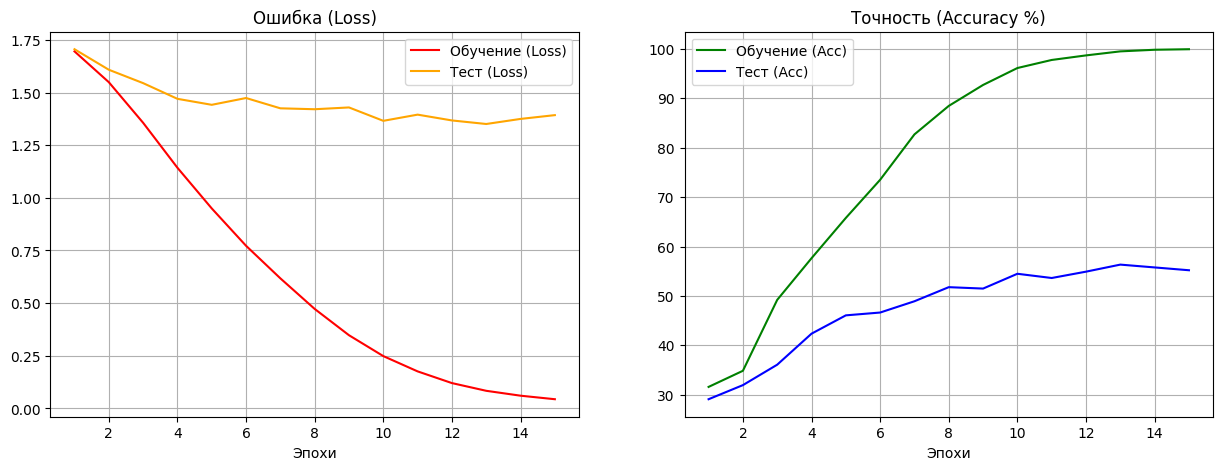

In [92]:
def plot_compare_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(15, 5))

    # Слева — Ошибка
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r', label='Обучение (Loss)')
    plt.plot(epochs, history['test_loss'], 'orange', label='Тест (Loss)')
    plt.title('Ошибка (Loss)')
    plt.xlabel('Эпохи')
    plt.legend()
    plt.grid(True)

    # Справа — Точность
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'g', label='Обучение (Acc)')
    plt.plot(epochs, history['test_acc'], 'b', label='Тест (Acc)')
    plt.title('Точность (Accuracy %)')
    plt.xlabel('Эпохи')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_compare_history(history)